In [43]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
import warnings
warnings.filterwarnings('ignore')

In [13]:
df = pd.read_csv(r"C:\Users\hp\Downloads\ML\temperature.csv")

In [14]:
df.head(5)

,Unnamed: 0,Datetime,Hourly_Temp
0,0,04-01-2022 00:00,20.867
1,1,04-01-2022 01:00,21.000
2,2,04-01-2022 02:00,20.867
3,3,04-01-2022 03:00,20.650
4,4,04-01-2022 04:00,20.400


In [32]:
df.drop('Unnamed: 0', axis=1, inplace=True)

In [33]:
df.head()

,Hourly_Temp
Datetime,
2022-01-04 00:00:00,20.867
2022-01-04 01:00:00,21.000
2022-01-04 02:00:00,20.867
2022-01-04 03:00:00,20.650
2022-01-04 04:00:00,20.400


In [15]:
df.shape

(7056, 3)

In [16]:
df.isnull().sum()

Unnamed: 0     0
Datetime       0
Hourly_Temp    0
dtype: int64

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7056 entries, 0 to 7055
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   7056 non-null   int64  
 1   Datetime     7056 non-null   object 
 2   Hourly_Temp  7056 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 165.5+ KB


In [18]:
df['Datetime'] = pd.to_datetime(df['Datetime'], format='%d-%m-%Y %H:%M')
df.set_index('Datetime', inplace=True)
temp_series = df['Hourly_Temp']


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 7056 entries, 2022-01-04 00:00:00 to 2022-10-24 23:00:00
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   7056 non-null   int64  
 1   Hourly_Temp  7056 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 165.4 KB


In [34]:
df.head()

,Hourly_Temp
Datetime,
2022-01-04 00:00:00,20.867
2022-01-04 01:00:00,21.000
2022-01-04 02:00:00,20.867
2022-01-04 03:00:00,20.650
2022-01-04 04:00:00,20.400


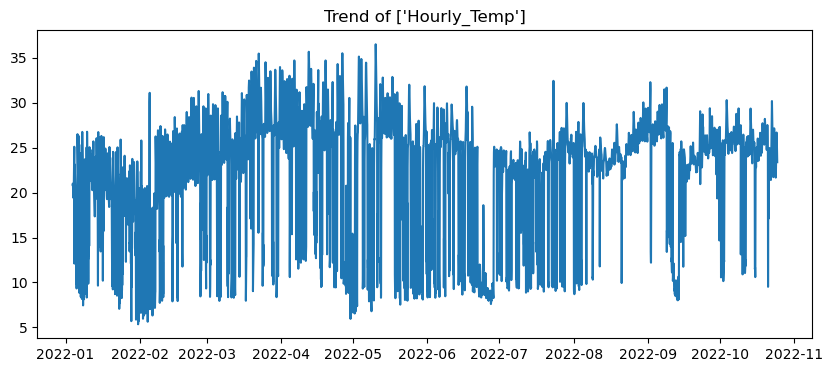

In [37]:
plt.figure(figsize=(10,4))
plt.plot(temp_series)
plt.title(f'Trend of {['Hourly_Temp']}')
plt.show()

In [21]:
train_size = int(len(temp_series) * 0.8)
train_t,test_t = temp_series[:train_size], temp_series[train_size:]
print(f"training points: {len(train_t)}")
print(f"testing points: {len(test_t)}")

training points: 5644
testing points: 1412


In [ ]:
print("ARIMA model train...")
if 'train_t' in locals():
    model = ARIMA(train_t, order=(1, 1, 1))
    results = model.fit()
    print("Training Over!")
else:
    print("⚠️ Error: Training data not available.")

ARIMA model train...
Training Over!


In [44]:
forecast = results.predict(start=len(train_t), end=len(train_t) + len(test_t) - 1, typ='levels')
forecast.index = test_t.index

rmse = np.sqrt(mean_squared_error(test_t, forecast))
mae = mean_absolute_error(test_t, forecast)
mape = mean_absolute_percentage_error(test_t, forecast)

print(f"RMSE (Average Error Dist): {rmse:.2f}")
print(f"MAE (Average Absolute Error): {mae:.2f}")
print(f"MAPE (Error in Percentage): {mape*100:.2f}%") 

RMSE (Average Error Dist): 5.37
MAE (Average Absolute Error): 3.15
MAPE (Error in Percentage): 21.20%


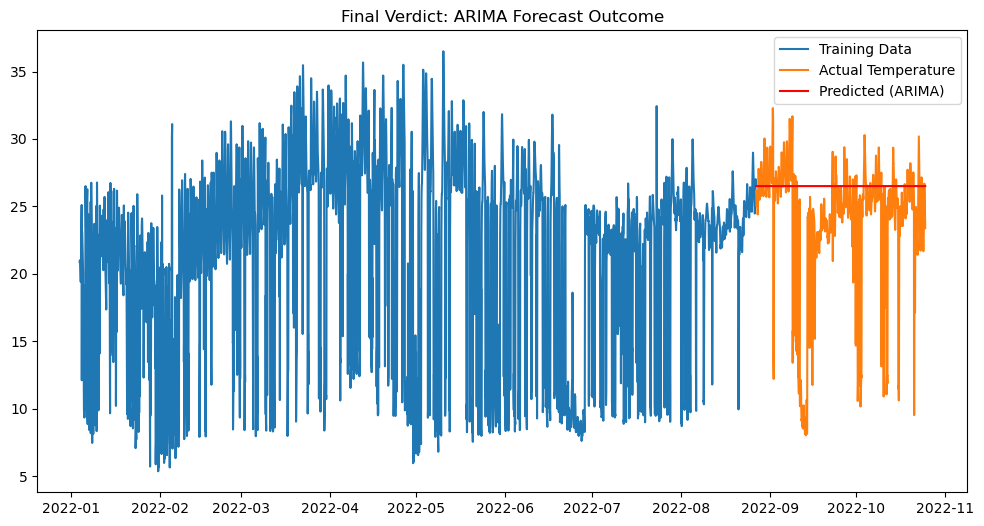

In [45]:
plt.figure(figsize=(12, 6))
plt.plot(train_t, label='Training Data')
plt.plot(test_t, label='Actual Temperature')
plt.plot(forecast, label='Predicted (ARIMA)', color='red')
plt.title('Final Verdict: ARIMA Forecast Outcome')
plt.legend()
plt.show()

In [46]:
df.tail(5)

,Hourly_Temp
Datetime,
2022-10-24 19:00:00,25.567
2022-10-24 20:00:00,25.183
2022-10-24 21:00:00,24.600
2022-10-24 22:00:00,23.986
2022-10-24 23:00:00,23.383


In [56]:
n_hours = int(input("Enter the number of hours to predict: "))

forecast = results.forecast(steps=n_hours)

print("\nForecast:")
print(forecast)



Forecast:
2022-08-27 04:00:00    26.501505
2022-08-27 05:00:00    26.502060
2022-08-27 06:00:00    26.502044
2022-08-27 07:00:00    26.502044
2022-08-27 08:00:00    26.502044
2022-08-27 09:00:00    26.502044
2022-08-27 10:00:00    26.502044
2022-08-27 11:00:00    26.502044
2022-08-27 12:00:00    26.502044
2022-08-27 13:00:00    26.502044
2022-08-27 14:00:00    26.502044
2022-08-27 15:00:00    26.502044
2022-08-27 16:00:00    26.502044
2022-08-27 17:00:00    26.502044
2022-08-27 18:00:00    26.502044
2022-08-27 19:00:00    26.502044
2022-08-27 20:00:00    26.502044
2022-08-27 21:00:00    26.502044
2022-08-27 22:00:00    26.502044
2022-08-27 23:00:00    26.502044
2022-08-28 00:00:00    26.502044
2022-08-28 01:00:00    26.502044
2022-08-28 02:00:00    26.502044
2022-08-28 03:00:00    26.502044
Freq: h, Name: predicted_mean, dtype: float64
